In [15]:
import sunpy
import sunpy.map
import numpy as np
from math import *
import astropy.units as u
from astropy.io import fits
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from sunpy.coordinates import frames
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from astropy.coordinates import SkyCoord
from matplotlib.patches import ConnectionPatch
import glob

In [3]:
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits'
rsm=fits.open(dir)
rsm.info()

Filename: D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\RSM20240618T211711_0000_HA.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   (2304, 2313)   int16   
  1  COMPRESSED_IMAGE    1 CompImageHDU     49   (2304, 2313, 118)   int16   


In [4]:
hacore = rsm[1].data[68, :, :]
hawing = rsm[1].data[-10, :, :]
coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = '2024-06-18 21:17:11', observer = 'earth', \
                     frame = frames.Helioprojective)
headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')
headercore = sunpy.map.make_fitswcs_header(hacore, coord_HIS,
                                       reference_pixel = \
                                       [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                       scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                       telescope = 'CHASE', instrument = 'RSM')

In [5]:
hawing_map = sunpy.map.Map(hawing, headerwing)
hacore_map = sunpy.map.Map(hacore, headercore)

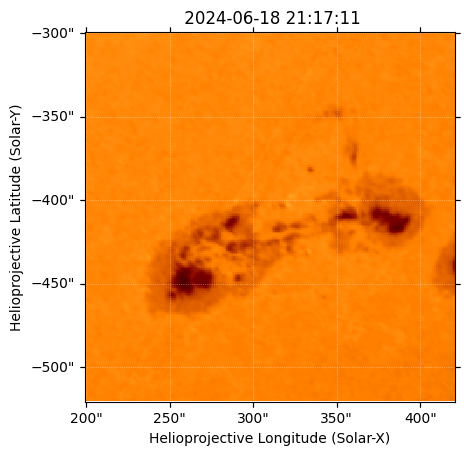

In [13]:
fig = plt.figure()
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)
sub_hawing_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean() )
plt.show()

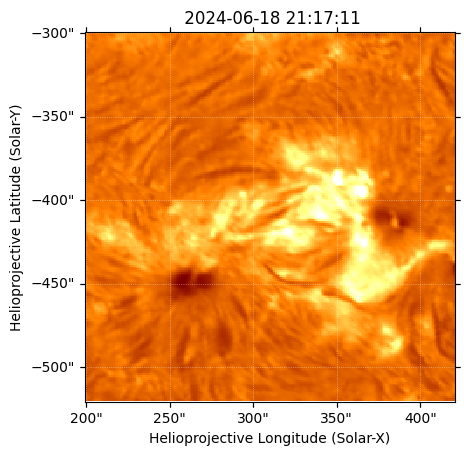

In [14]:
fig = plt.figure()
left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hacore_map.coordinate_frame)
top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hacore_map.coordinate_frame)
sub_hacore_map=hacore_map.submap(left_bottom,top_right=top_right)
sub_hacore_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hacore_map.data.mean() )
plt.show()

## 画movie

In [29]:
dir=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha\\'
files=sorted(glob.glob(dir+'*.fits'))
for i in range(25,50):
    rsm=fits.open(files[i])
    #hacore = rsm[1].data[68, :, :]
    hawing = rsm[1].data[28, :, :]
    coord_HIS = SkyCoord(0 * u.arcsec, 0 * u.arcsec, obstime = rsm[1].header['DATE_OBS'], observer = 'earth', \
                        frame = frames.Helioprojective)
    headerwing = sunpy.map.make_fitswcs_header(hawing, coord_HIS,
                                        reference_pixel = \
                                        [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
                                        scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
                                        telescope = 'CHASE', instrument = 'RSM')
    # headercore = sunpy.map.make_fitswcs_header(hacore, coord_HIS,
    #                                     reference_pixel = \
    #                                     [rsm[1].header['CRPIX1'], rsm[1].header['CRPIX2']] * u.pixel,
    #                                     scale = [0.5218 * 2, 0.5218 * 2] * u.arcsec / u.pixel,
    #                                     telescope = 'CHASE', instrument = 'RSM')
    hawing_map = sunpy.map.Map(hawing, headerwing)
    #hacore_map = sunpy.map.Map(hacore, headercore)
    #画线翼的图像
    fig = plt.figure()
    left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hawing_map.coordinate_frame)
    top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hawing_map.coordinate_frame)
    sub_hawing_map=hawing_map.submap(left_bottom,top_right=top_right)
    sub_hawing_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hawing_map.data.mean() )
    #plt.show()
    dir_wing=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hawing\\'
    plt.savefig(dir_wing+files[i][-28:-13]+'.png',dpi=300)
    plt.close()
    # fig = plt.figure()
    # left_bottom=SkyCoord(Tx=200*u.arcsec,Ty=-520*u.arcsec,frame=hacore_map.coordinate_frame)
    # top_right=SkyCoord(Tx=420*u.arcsec,Ty=-300*u.arcsec,frame=hacore_map.coordinate_frame)
    # sub_hacore_map=hacore_map.submap(left_bottom,top_right=top_right)
    # sub_hacore_map.plot(cmap = 'afmhot', vmin = 0, vmax = 2 * sub_hacore_map.data.mean() )
    # #plt.show()
    # dir_core=r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hacore\\'
    # plt.savefig(dir_core+files[i][-28:-13]+'.png',dpi=300)
    # plt.close()

In [30]:
import cv2
import os

def images_to_video(image_folder, output_folder, video_name, fps):
    images = [img for img in os.listdir(image_folder) if img.endswith(".png")]
    images=images[1::2]
    frame = cv2.imread(os.path.join(image_folder, images[0]))
    height, width, layers = frame.shape

    output_path = os.path.join(output_folder, video_name)
    video = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'XVID'), fps, (width,height))

    for image in images:
        video.write(cv2.imread(os.path.join(image_folder, image)))

    cv2.destroyAllWindows()
    video.release()
# images_to_video(r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hacore\\'
#                 ,r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\\','CHASE_Ha_core.avi',3)
images_to_video(r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\hawing\\'
                ,r'D:\Learning\PHD1st\magnetic_reconnecion\data\CHASE_Ha_image\\','CHASE_Ha_wing.avi',3)

In [21]:
a='RSM20240618T194219_0000_HA.fits'
print(a[-28:-13])

20240618T194219
